# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

In [62]:
#connect google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [63]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = '/content/drive/My Drive/Data_Eng_300/airline_2019.csv'

## TO DO: read_csv()
airline = pd.read_csv(DATA_DIR, usecols=use_cols)

## Check the shape of the loaded data
airline.shape

(76616, 29)

#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis

In [64]:
## 1.1 Rename a few columns
airline.rename(columns={"Reporting_Airline": "UniqueCarrier",
                                  "Flight_Number_Reporting_Airline":"FlightNum",
                                  "Tail_Number":"TailNum"},
                         inplace=True
                         )

## 1.2 Random sampling for further analysis
sample_airline = airline.sample(n=20000, random_state=42)
print(sample_airline.shape)
sample_airline.head()

(20000, 29)


,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
66952,2019,5,9,4,DL,N993AT,2182,BNA,DTW,1859,...,0.0,96.0,82.0,67.0,456.0,NaN,NaN,NaN,NaN,NaN
40788,2019,4,13,6,UA,N63890,2152,IAH,SEA,1950,...,0.0,289.0,293.0,243.0,1874.0,14.0,0.0,4.0,0.0,3.0
58392,2019,12,18,3,WN,N8655D,2233,SEA,OAK,1705,...,0.0,120.0,114.0,95.0,672.0,9.0,0.0,0.0,0.0,13.0
42540,2019,7,5,5,AA,N402AN,601,ORD,PHX,1335,...,0.0,222.0,274.0,193.0,1440.0,9.0,0.0,52.0,0.0,0.0
29690,2019,10,4,5,DL,N395DZ,1984,AUS,ATL,600,...,0.0,133.0,131.0,109.0,813.0,NaN,NaN,NaN,NaN,NaN


### 2. Basic EDA

In [65]:
## Print first 5 rows to check how the data looks like
sample_airline.head()

,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
66952,2019,5,9,4,DL,N993AT,2182,BNA,DTW,1859,...,0.0,96.0,82.0,67.0,456.0,NaN,NaN,NaN,NaN,NaN
40788,2019,4,13,6,UA,N63890,2152,IAH,SEA,1950,...,0.0,289.0,293.0,243.0,1874.0,14.0,0.0,4.0,0.0,3.0
58392,2019,12,18,3,WN,N8655D,2233,SEA,OAK,1705,...,0.0,120.0,114.0,95.0,672.0,9.0,0.0,0.0,0.0,13.0
42540,2019,7,5,5,AA,N402AN,601,ORD,PHX,1335,...,0.0,222.0,274.0,193.0,1440.0,9.0,0.0,52.0,0.0,0.0
29690,2019,10,4,5,DL,N395DZ,1984,AUS,ATL,600,...,0.0,133.0,131.0,109.0,813.0,NaN,NaN,NaN,NaN,NaN


In [66]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for all columns
    res = pd_frame.describe(include='all').transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    #
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res

res = get_info(sample_airline)
res

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing_percent,unique_val,var_type
Year,20000.0,NaN,NaN,NaN,2019.0,0.0,2019.0,2019.0,2019.0,2019.0,2019.0,0.00000,1,Categorical
Month,20000.0,NaN,NaN,NaN,6.587,3.395321,1.0,4.0,7.0,10.0,12.0,0.00000,12,Categorical
DayofMonth,20000.0,NaN,NaN,NaN,15.6743,8.723481,1.0,8.0,16.0,23.0,31.0,0.00000,31,Categorical
DayOfWeek,20000.0,NaN,NaN,NaN,3.91705,1.991323,1.0,2.0,4.0,6.0,7.0,0.00000,7,Categorical
UniqueCarrier,20000,17,WN,3654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,17,Categorical
TailNum,19953,5111,N784SW,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00235,5111,Continuous
FlightNum,20000.0,NaN,NaN,NaN,2553.8451,1799.910189,1.0,1017.0,2154.0,3919.0,7439.0,0.00000,5679,Continuous
Origin,20000,333,ATL,1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,333,Continuous
Dest,20000,338,ATL,1096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,338,Continuous
CRSDepTime,20000.0,NaN,NaN,NaN,1331.1956,492.551215,5.0,915.0,1323.0,1739.0,2359.0,0.00000,1153,Continuous


### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

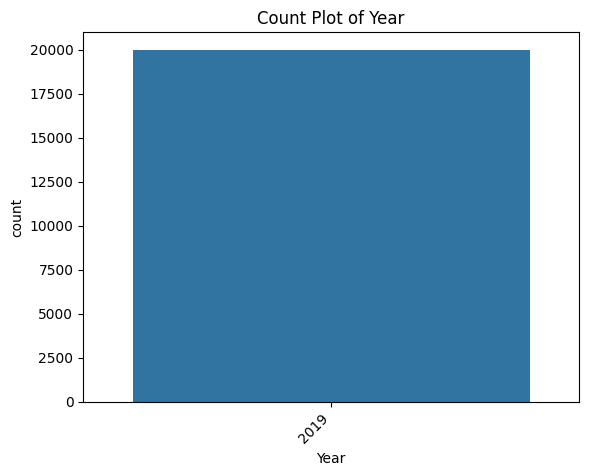

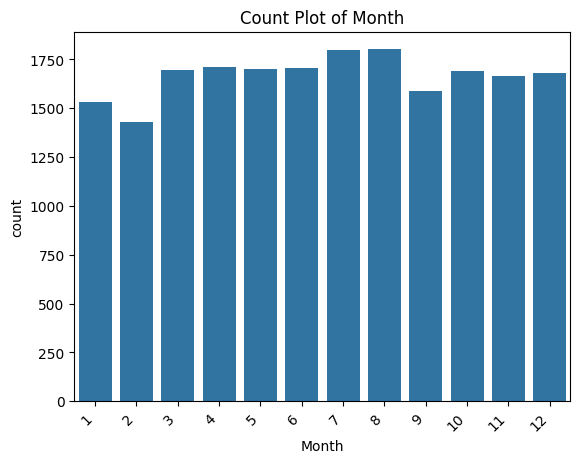

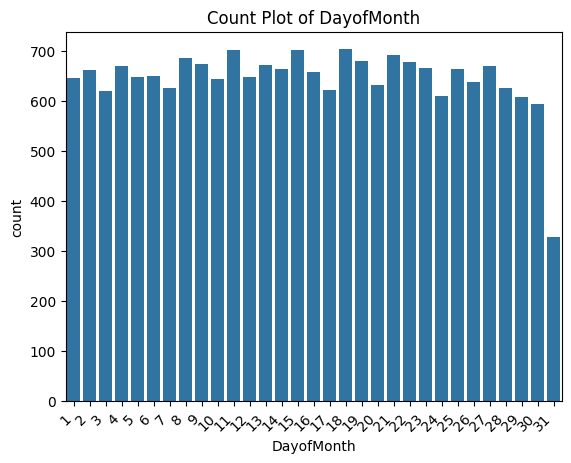

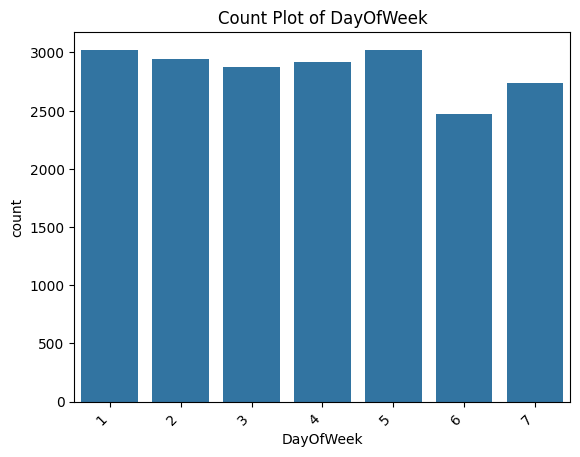

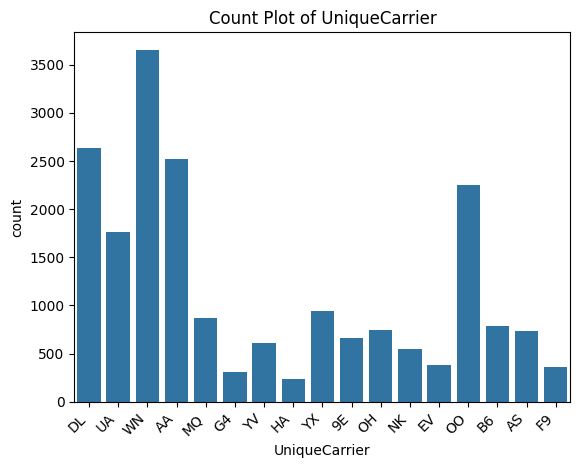

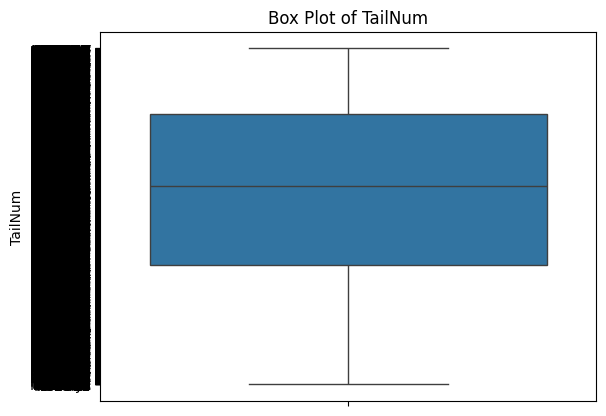

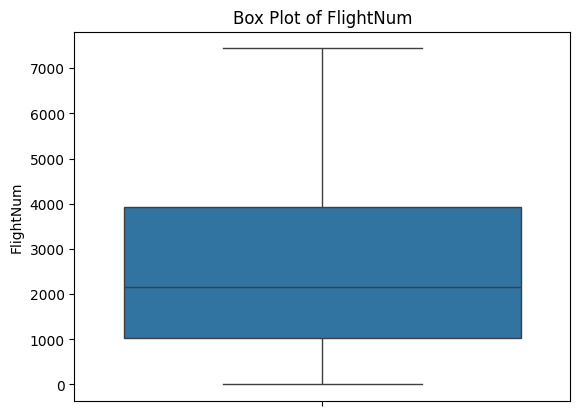

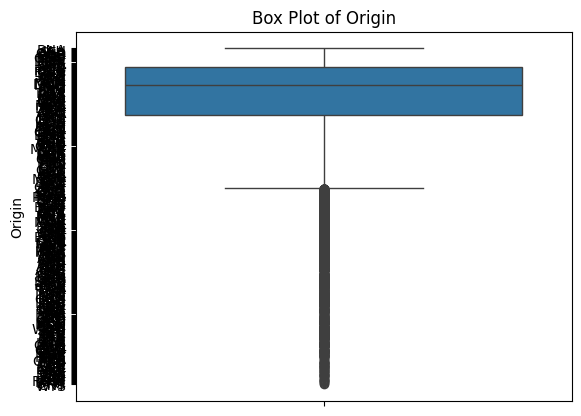

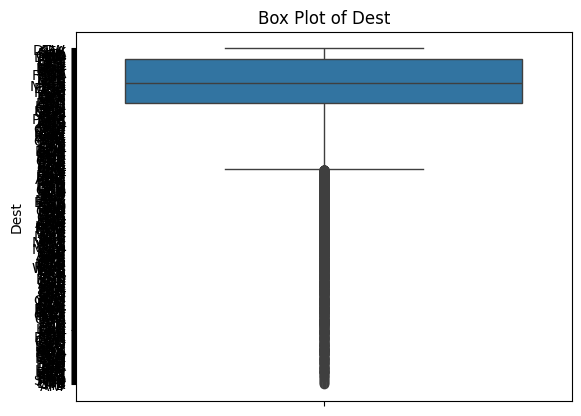

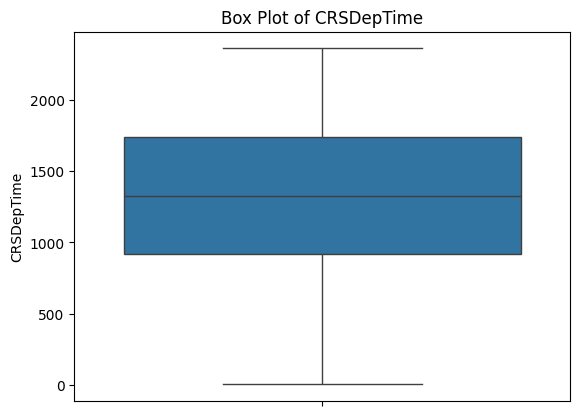

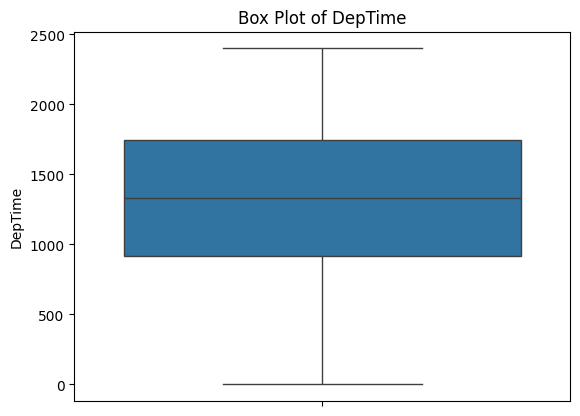

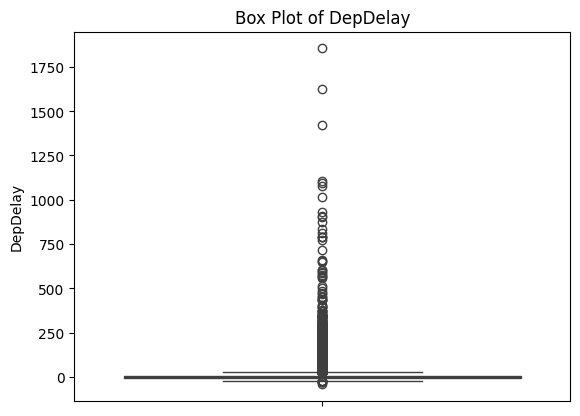

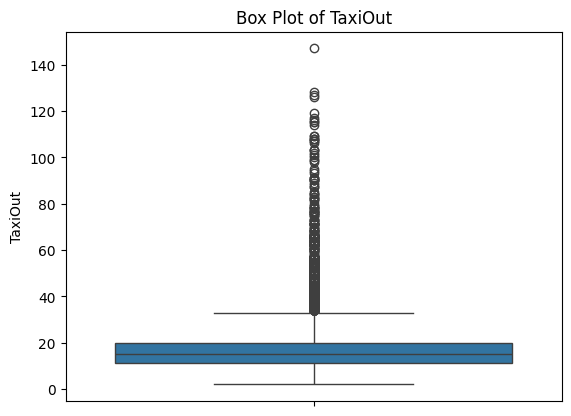

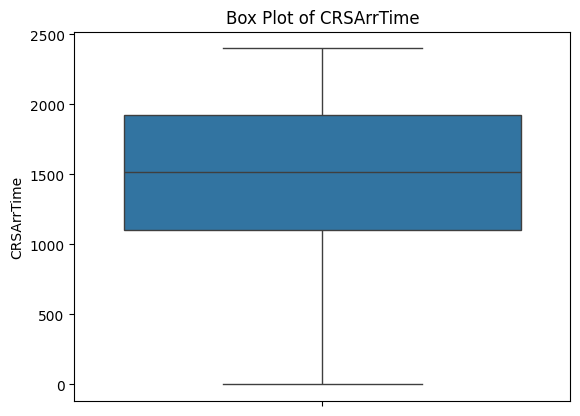

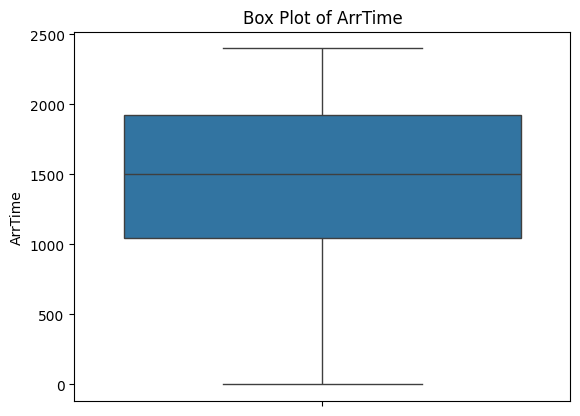

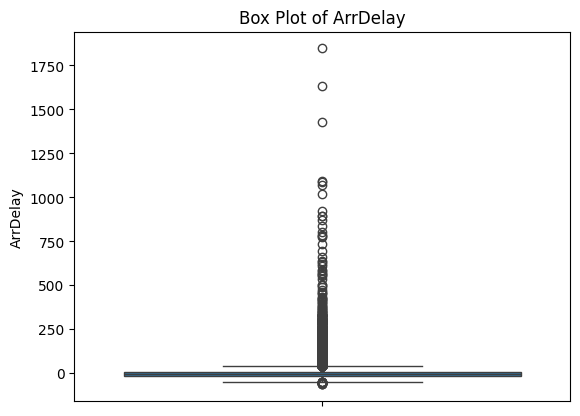

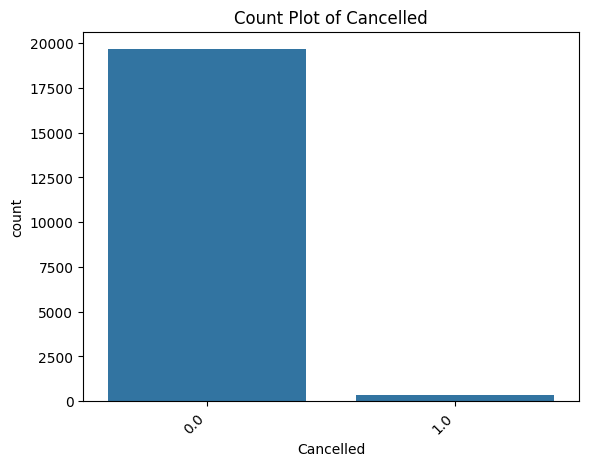

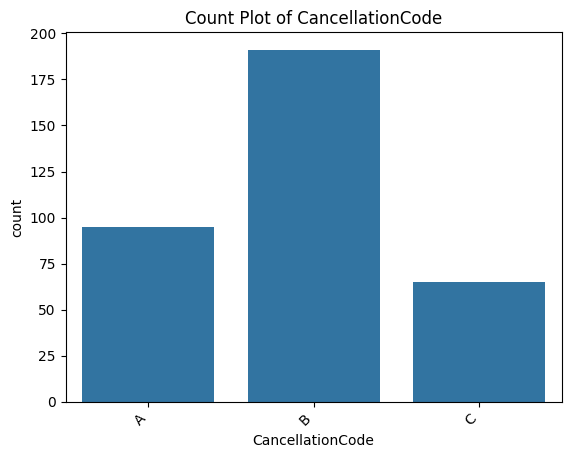

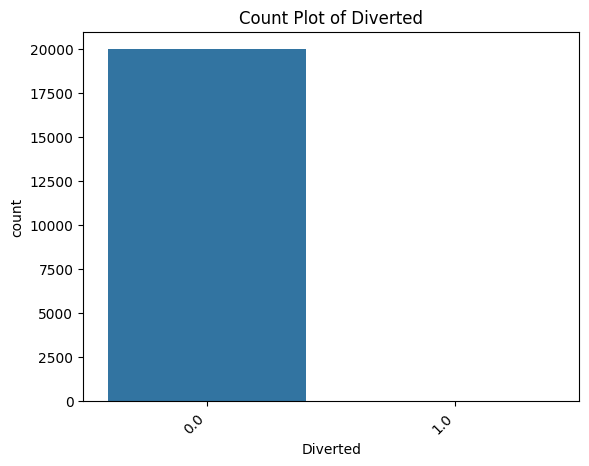

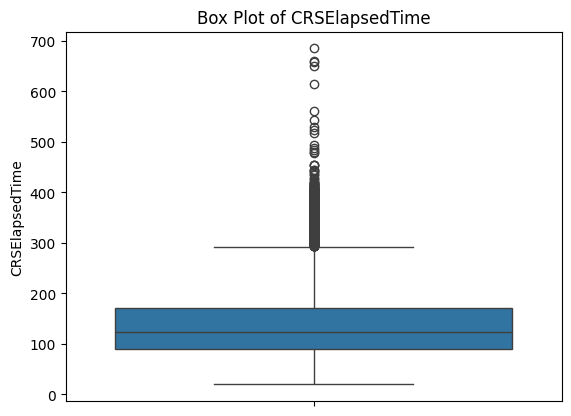

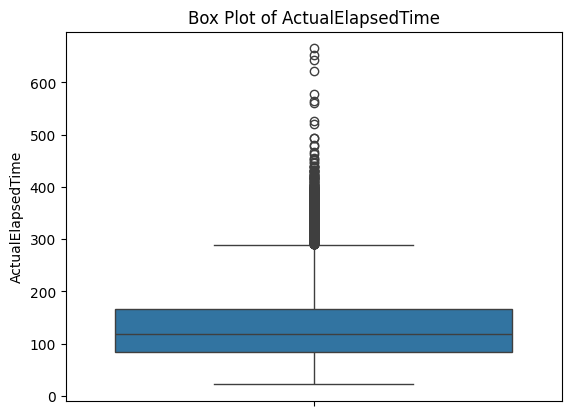

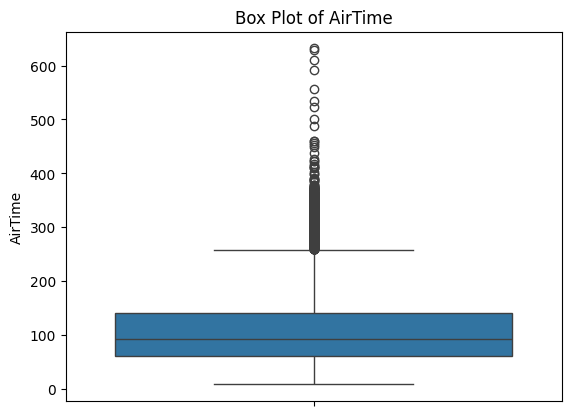

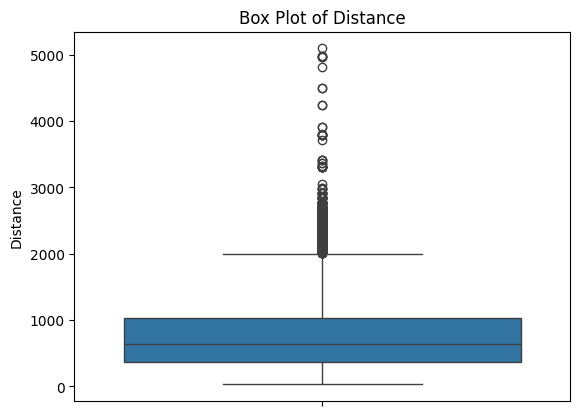

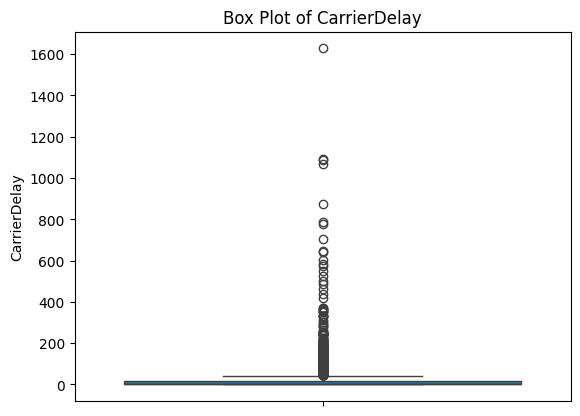

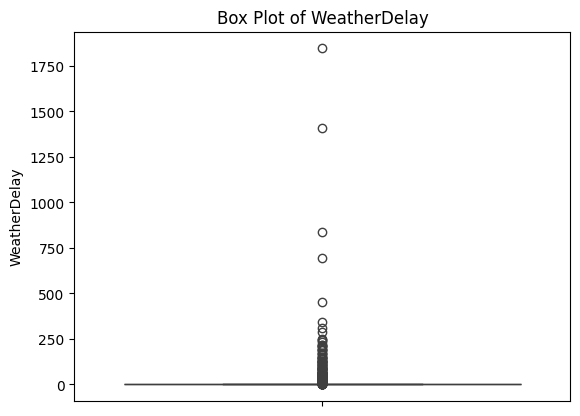

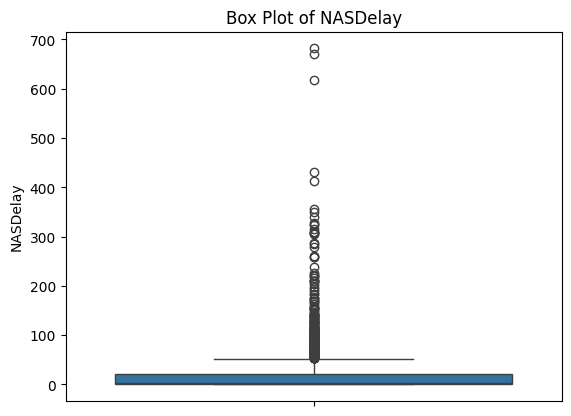

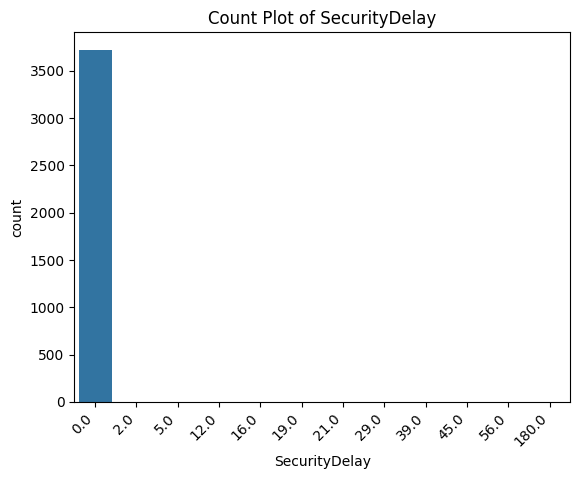

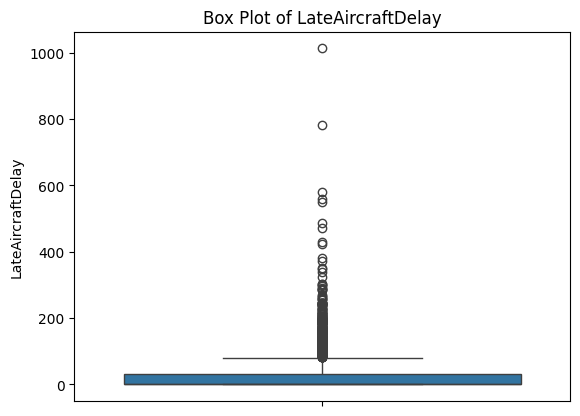

In [67]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

import matplotlib.pyplot as plt
import seaborn as sns

for col in res.index:
  if res.loc[col, 'var_type'] == 'Continuous':
    sns.boxplot(y=sample_airline[col])
    plt.title(f'Box Plot of {col}')
  else:
    if sample_airline[col].nunique() < 50:
      sns.countplot(x=sample_airline[col])
      plt.title(f'Count Plot of {col}')
      plt.xticks(rotation=45, ha='right')
  plt.show()

In [68]:
## 3.2 Calculate the missing value percentage of each column
display(res[['missing_percent']].sort_values(by='missing_percent', ascending=False))

,missing_percent
CancellationCode,0.98245
LateAircraftDelay,0.81330
SecurityDelay,0.81330
NASDelay,0.81330
WeatherDelay,0.81330
CarrierDelay,0.81330
ActualElapsedTime,0.01965
ArrDelay,0.01965
AirTime,0.01965
ArrTime,0.01815


/tmp/ipykernel_832/686351401.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sample_airline, x='DayofMonth', palette='viridis')


Text(0, 0.5, 'Number of Flights')

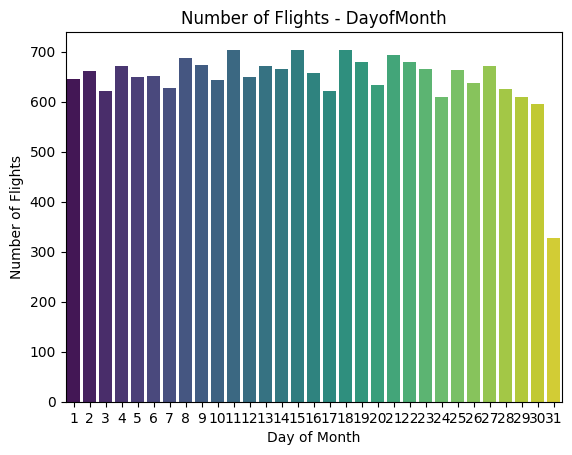

In [69]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek
sns.countplot(data=sample_airline, x='DayofMonth', palette='viridis')

## Visualize with Barchart
plt.title('Number of Flights - DayofMonth')
plt.xlabel('Day of Month')
plt.ylabel('Number of Flights')

/tmp/ipykernel_832/4177572663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sample_airline, x='DayOfWeek', palette='magma')


Text(0, 0.5, 'Number of Flights')

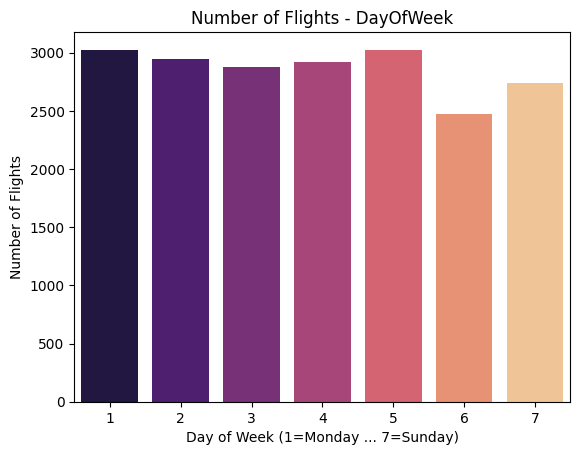

In [70]:
sns.countplot(data=sample_airline, x='DayOfWeek', palette='magma')
plt.title('Number of Flights - DayOfWeek')
plt.xlabel('Day of Week (1=Monday ... 7=Sunday)')
plt.ylabel('Number of Flights')

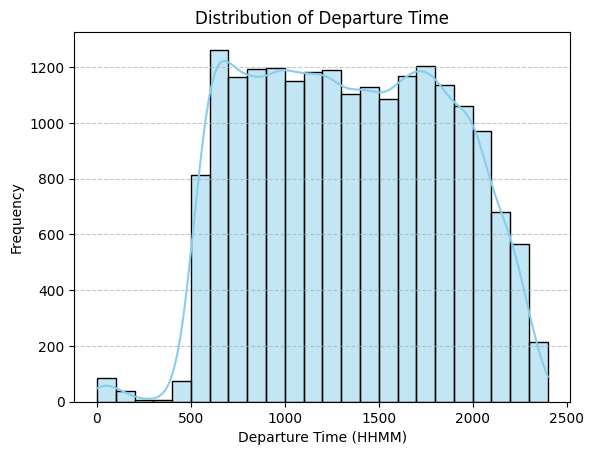

In [71]:
## 3.4.1 Histogram of Departure Time
sns.histplot(sample_airline['DepTime'].dropna(), bins=24, kde=True, color='skyblue')
plt.title('Distribution of Departure Time')
plt.xlabel('Departure Time (HHMM)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

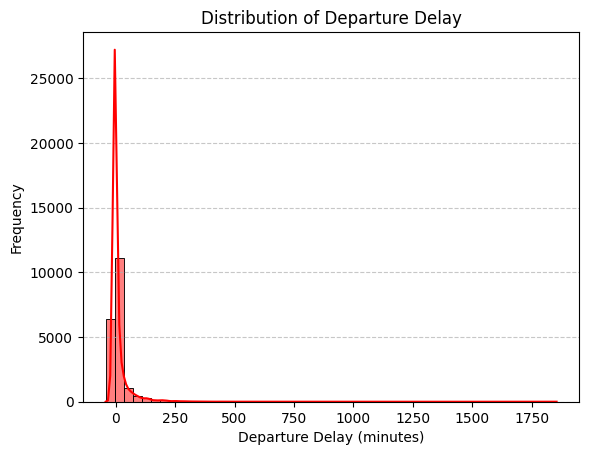

In [72]:
## 3.4.2 Histogram of arrival and departure delays
sns.histplot(sample_airline['DepDelay'].dropna(), bins=50, kde=True, color='red')
plt.title('Distribution of Departure Delay')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

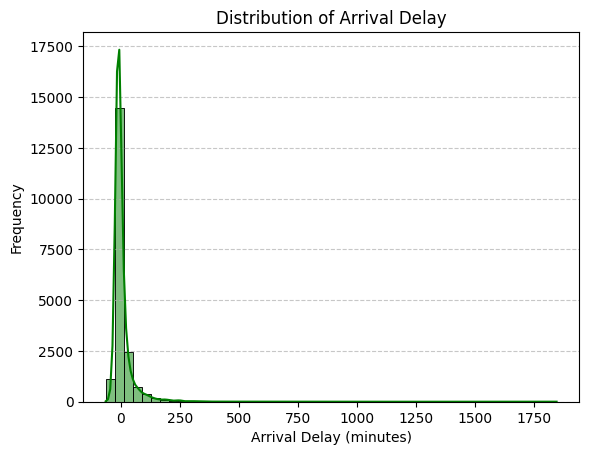

In [73]:
sns.histplot(sample_airline['ArrDelay'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Arrival Delay')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

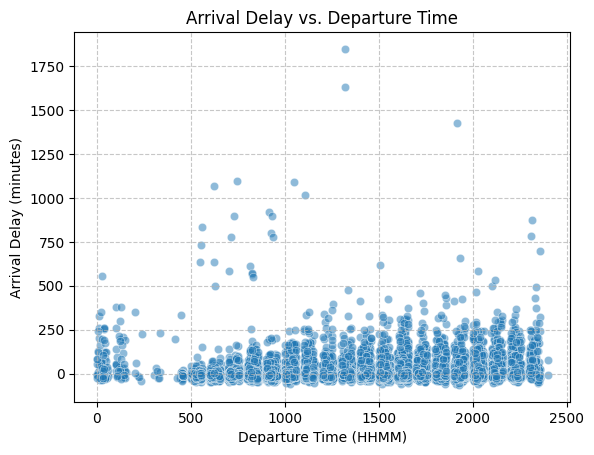

In [74]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot
sns.scatterplot(data=sample_airline, x='DepTime', y='ArrDelay', alpha=0.5)
plt.title('Arrival Delay vs. Departure Time')
plt.xlabel('Departure Time (HHMM)')
plt.ylabel('Arrival Delay (minutes)')
plt.grid(True, linestyle='--', alpha=0.7)

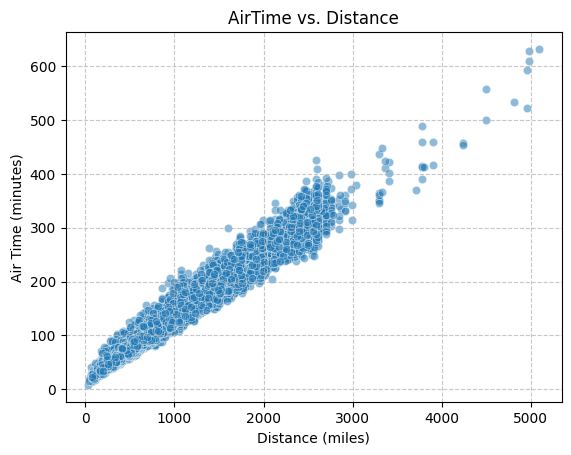

In [75]:
## 3.5.2 bivariate analysis: distance and airtimes
sns.scatterplot(data=sample_airline, x='Distance', y='AirTime', alpha=0.5)
plt.title('AirTime vs. Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Air Time (minutes)')
plt.grid(True, linestyle='--', alpha=0.7)

### 4. Feature engineering and cleaning

In [76]:
## 4.1 creating a categorical column for weekday
## {      1: 'Monday',
##        2: 'Tuesday',
##        3: 'Wednesday',
##        4: 'Thursday',
##        5: 'Friday',
##        6: 'Saturday',
##        7: 'Sunday'}
weekday_mapping = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

sample_airline['WeekdayName'] = sample_airline['DayOfWeek'].map(weekday_mapping)
display(sample_airline[['DayOfWeek', 'WeekdayName']].head())

,DayOfWeek,WeekdayName
66952,4,Thursday
40788,6,Saturday
58392,3,Wednesday
42540,5,Friday
29690,5,Friday


In [77]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)
#DepDelay and arrDelay have neg vals
sample_airline['DepDelay'] = sample_airline['DepDelay'].apply(lambda x: max(0, x) if pd.notna(x) else np.nan) #
sample_airline['DepDelay_New'] = np.log1p(sample_airline['DepDelay']) #log(1+x)

sample_airline['ArrDelay'] = sample_airline['ArrDelay'].apply(lambda x: max(0, x) if pd.notna(x) else np.nan)
sample_airline['ArrDelay_New'] = np.log1p(sample_airline['ArrDelay'])
sample_airline

,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,WeekdayName,DepDelay_New,ArrDelay_New
66952,2019,5,9,4,DL,N993AT,2182,BNA,DTW,1859,...,67.0,456.0,NaN,NaN,NaN,NaN,NaN,Thursday,0.000000,0.000000
40788,2019,4,13,6,UA,N63890,2152,IAH,SEA,1950,...,243.0,1874.0,14.0,0.0,4.0,0.0,3.0,Saturday,2.890372,3.091042
58392,2019,12,18,3,WN,N8655D,2233,SEA,OAK,1705,...,95.0,672.0,9.0,0.0,0.0,0.0,13.0,Wednesday,3.367296,3.135494
42540,2019,7,5,5,AA,N402AN,601,ORD,PHX,1335,...,193.0,1440.0,9.0,0.0,52.0,0.0,0.0,Friday,2.302585,4.127134
29690,2019,10,4,5,DL,N395DZ,1984,AUS,ATL,600,...,109.0,813.0,NaN,NaN,NaN,NaN,NaN,Friday,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37213,2019,6,30,7,OO,N466SW,5201,SFO,MRY,1300,...,23.0,77.0,0.0,0.0,15.0,0.0,65.0,Sunday,4.189655,4.394449
43024,2019,5,6,1,AA,N946AN,1097,DFW,TUS,1420,...,109.0,813.0,NaN,NaN,NaN,NaN,NaN,Monday,2.890372,1.386294
58497,2019,3,29,5,DL,N332NB,1729,BNA,MSP,1630,...,97.0,695.0,NaN,NaN,NaN,NaN,NaN,Friday,1.609438,0.000000
17841,2019,1,18,5,AS,N840VA,1176,SEA,SAN,1005,...,124.0,1050.0,NaN,NaN,NaN,NaN,NaN,Friday,1.609438,0.000000


In [78]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75
sample_airline['DecimalDepTime'] = sample_airline['CRSDepTime'] // 100 + (sample_airline['CRSDepTime'] % 100) / 60
display(sample_airline[['CRSDepTime', 'DecimalDepTime']].head())

,CRSDepTime,DecimalDepTime
66952,1859,18.983333
40788,1950,19.833333
58392,1705,17.083333
42540,1335,13.583333
29690,600,6.000000


,Distance,AirTime,speed
66952,456.0,67.0,408.358209
40788,1874.0,243.0,462.716049
58392,672.0,95.0,424.421053
42540,1440.0,193.0,447.668394
29690,813.0,109.0,447.522936


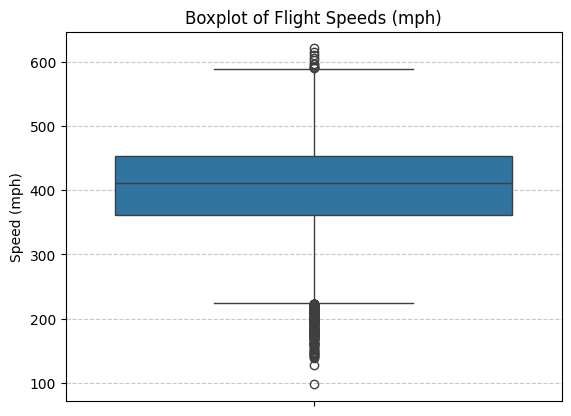

In [79]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)
sample_airline['speed'] = sample_airline['Distance'] / (sample_airline['AirTime'] / 60)
display(sample_airline[['Distance', 'AirTime', 'speed']].head())

## boxplots of average speeds
sns.boxplot(y=sample_airline['speed'].dropna())
plt.title('Boxplot of Flight Speeds (mph)')
plt.ylabel('Speed (mph)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [80]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.
high_speed_flights = sample_airline[sample_airline['speed'] > 650]
proportion_high_speed = len(high_speed_flights) / len(sample_airline)
print(f"Number of flights with speed > 650 mph: {len(high_speed_flights)}")
print(f"Proportion of flights with speed > 650 mph: {proportion_high_speed:.4f}")

Number of flights with speed > 650 mph: 0
Proportion of flights with speed > 650 mph: 0.0000


### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [81]:
## Save transformed data

path = '/content/drive/My Drive/Data_Eng_300/airline_2019_transformed.parquet'
sample_airline.to_parquet(path, index=False)
print(f"Data successfully saved to {path}")

Data successfully saved to /content/drive/My Drive/Data_Eng_300/airline_2019_transformed.parquet
